# 01 — EDA Criteo Uplift Dataset

Giai đoạn 1 / Tuần 1 (xem `planning/CAUSAL_UPLIFT_PLAN.md` mục 4, `planning/sprints.md` Tuần 1).

Mục tiêu: kiểm tra schema, tỉ lệ treatment/control, conversion rate, randomization
(propensity AUC + KS-test), missing/outlier trên f0-f11, và chốt chiến lược sample
cho các giai đoạn sau.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.paths import OUTPUT_DIR
from src.data import (
    FEATURES,
    load_criteo_full,
    stratified_sample,
    propensity_auc,
    ks_test_by_treatment,
)

pd.set_option("display.max_columns", 20)

## 1. Load dữ liệu đầy đủ

In [2]:
df = load_criteo_full(dtype_f32=True)
print("shape:", df.shape)
assert df.shape == (13_979_592, 16), "Schema/row count không khớp kỳ vọng — dừng lại, kiểm tra lại dữ liệu"
df.head()


shape: (13979592, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616364,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616364,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616364,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616364,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


## 2. Schema, tỉ lệ treatment/control, conversion rate

In [3]:
schema_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
})
schema_summary


,dtype,n_missing
f0,float32,0
f1,float32,0
f2,float32,0
f3,float32,0
f4,float32,0
f5,float32,0
f6,float32,0
f7,float32,0
f8,float32,0
f9,float32,0


In [4]:
treatment_rate = df["treatment"].mean()
conversion_rate = df["conversion"].mean()
visit_rate = df["visit"].mean()
exposure_rate = df["exposure"].mean()

print(f"treatment rate : {treatment_rate:.4f} (kỳ vọng ~0.85)")
print(f"conversion rate: {conversion_rate:.5f} (kỳ vọng ~0.0029)")
print(f"visit rate     : {visit_rate:.4f}")
print(f"exposure rate  : {exposure_rate:.4f}")

assert 0.83 <= treatment_rate <= 0.87
assert 0.0025 <= conversion_rate <= 0.0035


treatment rate : 0.8500 (kỳ vọng ~0.85)
conversion rate: 0.00292 (kỳ vọng ~0.0029)
visit rate     : 0.0470
exposure rate  : 0.0306


## 3. Missing / outlier trên f0-f11

In [5]:
missing_counts = df[FEATURES].isna().sum()
print("Missing values per feature:")
print(missing_counts)
assert (missing_counts == 0).all(), "Có missing values trong f0-f11 — cần xử lý trước khi modeling"

feature_stats = df[FEATURES].describe().T
feature_stats


Missing values per feature:
f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
f0,13979592.0,19.620296,5.377464,12.616364,12.616364,21.923413,24.436459,26.745255
f1,13979592.0,10.069978,0.104756,10.059654,10.059654,10.059654,10.059654,16.344187
f2,13979592.0,8.446583,0.299316,8.214383,8.214383,8.214383,8.723335,9.051962
f3,13979592.0,4.178923,1.336645,-8.398387,4.679882,4.679882,4.679882,4.679882
f4,13979592.0,10.338838,0.343308,10.280525,10.280525,10.280525,10.280525,21.123508
f5,13979592.0,4.028512,0.431097,-9.011891,4.115453,4.115453,4.115453,4.115453
f6,13979592.0,-4.155355,4.577914,-31.429783,-6.699321,-2.411115,0.294443,0.294443
f7,13979592.0,5.101766,1.205248,4.833815,4.833815,4.833815,4.833815,11.998401
f8,13979592.0,3.933581,0.056660,3.635107,3.910792,3.971858,3.971858,3.971858
f9,13979592.0,16.027639,7.018975,13.190056,13.190056,13.190056,13.190056,75.295021


In [6]:
# Outlier check: đếm % giá trị nằm ngoài [mean - 5*std, mean + 5*std] cho mỗi feature
outlier_pct = {}
for f in FEATURES:
    mu, sigma = df[f].mean(), df[f].std()
    lo, hi = mu - 5 * sigma, mu + 5 * sigma
    outlier_pct[f] = float(((df[f] < lo) | (df[f] > hi)).mean() * 100)

outlier_summary = pd.Series(outlier_pct, name="pct_outside_5sigma")
outlier_summary


f0     0.000000
f1     1.230007
f2     0.000000
f3     0.503055
f4     0.823701
f5     0.947123
f6     0.000336
f7     1.573658
f8     0.000236
f9     0.225758
f10    1.960823
f11    0.530702
Name: pct_outside_5sigma, dtype: float64

## 4. Assignment balance diagnostics

`propensity_auc` fit `LogisticRegression(treatment ~ f0..f11)` trên sample 5% (stratify theo
`treatment`×`conversion`, seed=42). AUC gần 0,5 cho thấy model này có ít khả năng phân biệt
hai arm; nó không tự chứng minh assignment mechanism. `ks_test_by_treatment` so từng feature.

**Diễn giải KS-test:** với N ≈ 700K/nhóm ở sample 5%, KS-test có power cao và có thể phát
hiện chênh lệch có effect size nhỏ. Báo cả statistic/effect size thay vì chỉ dùng p-value.
Propensity AUC và KS là diagnostics bổ sung; provenance của thí nghiệm mới là căn cứ cho
assignment mechanism.

In [7]:
sample_5pct = stratified_sample(df, frac=0.05, seed=42)
print("sample shape:", sample_5pct.shape)
print(f"sample treatment rate : {sample_5pct['treatment'].mean():.4f} (full: {treatment_rate:.4f})")
print(f"sample conversion rate: {sample_5pct['conversion'].mean():.5f} (full: {conversion_rate:.5f})")


sample shape: (698980, 16)
sample treatment rate : 0.8500 (full: 0.8500)
sample conversion rate: 0.00292 (full: 0.00292)


In [8]:
auc = propensity_auc(sample_5pct, FEATURES, seed=42)
print(f"Propensity AUC (treatment ~ f0..f11, sample 5%): {auc:.4f}")

if 0.48 <= auc <= 0.52:
    balance_diagnostic_interpretation = "Propensity AUC gần 0,5 trong diagnostic này; kết quả không tự chứng minh random assignment."
elif auc > 0.6:
    balance_diagnostic_interpretation = "AUC > 0,6: feature có khả năng phân biệt treatment/control; kiểm tra assignment và data pipeline trước khi modeling."
else:
    balance_diagnostic_interpretation = f"AUC = {auc:.4f}: nằm ngoài diagnostic band [0,48; 0,52] nhưng không vượt 0,6; báo statistic và kiểm tra độ nhạy theo model."

print(balance_diagnostic_interpretation)


D:\GitHub\Causal-Uplift-for-Activation-and-Retention\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Propensity AUC (treatment ~ f0..f11, sample 5%): 0.5098
Propensity AUC gần 0,5 trong diagnostic này; kết quả không tự chứng minh randomization.


In [9]:
ks_results = ks_test_by_treatment(sample_5pct, FEATURES).sort_values("p_value")
ks_results


,feature,ks_stat,p_value
6,f6,0.014573,7.185688e-17
3,f3,0.013780,3.952034e-15
0,f0,0.009853,6.068333e-08
8,f8,0.006512,1.038768e-03
9,f9,0.005545,8.298587e-03
5,f5,0.005151,1.759046e-02
7,f7,0.005151,1.759154e-02
2,f2,0.004798,3.292943e-02
10,f10,0.002468,6.487700e-01
1,f1,0.002230,7.663322e-01


In [10]:
n_significant = (ks_results["p_value"] < 0.01).sum()
print(f"{n_significant}/{len(FEATURES)} feature có KS p-value < 0.01 ở sample 5% (N≈700K/nhóm).")
print("Với N lớn, p-value nhỏ có thể đi kèm KS statistic nhỏ; báo cả effect size và diagnostic tổng hợp.")
print("kết luận randomization dựa trên propensity AUC ở trên, không dựa trên KS-test riêng lẻ.")


5/12 feature có KS p-value < 0.01 ở sample 5% (N≈700K/nhóm).
Với N lớn, p-value nhỏ có thể đi kèm KS statistic nhỏ; báo cả effect size và diagnostic tổng hợp.
kết luận randomization dựa trên propensity AUC ở trên, không dựa trên KS-test riêng lẻ.


## 5. Trực quan hoá phân phối & so sánh treatment/control

Bổ sung phần nhìn trực quan cho các kết quả số học ở mục 2-4: tỉ lệ outcome theo nhóm,
phân phối f0-f11 giữa treatment/control (đối chiếu trực quan với KS-test), outlier, và
tương quan giữa các đặc trưng.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
CONTROL_COLOR, TREATMENT_COLOR = "#b9691f", "#0e7c7b"

### 5.1 Tỉ lệ outcome theo nhóm treatment/control

Đây là biểu đồ minh chứng trực tiếp cho câu hỏi kinh doanh: quảng cáo có thực sự làm tăng
conversion/visit/exposure hay không, tính trên toàn bộ 13.98M dòng (không sample).

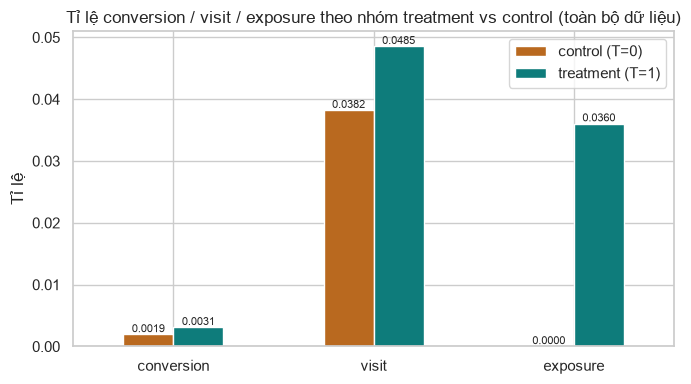

Uplift thô (treatment - control):
conversion    0.00115
visit         0.01034
exposure      0.03604
dtype: float64


In [12]:
rates_by_group = df.groupby("treatment")[["conversion", "visit", "exposure"]].mean().T
rates_by_group.columns = ["control (T=0)", "treatment (T=1)"]

ax = rates_by_group.plot(kind="bar", figsize=(7, 4), color=[CONTROL_COLOR, TREATMENT_COLOR])
ax.set_ylabel("Tỉ lệ")
ax.set_title("Tỉ lệ conversion / visit / exposure theo nhóm treatment vs control (toàn bộ dữ liệu)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Uplift thô (treatment - control):")
print((rates_by_group["treatment (T=1)"] - rates_by_group["control (T=0)"]).round(5))

### 5.2 Phân phối f0-f11: treatment vs control

So khớp trực quan với bảng KS-test ở mục 4 (tính trên `sample_5pct` để nhẹ) — 3 feature có
KS p-value nhỏ nhất (f6, f3, f0) được kỳ vọng lệch rõ nhất giữa 2 đường phân phối; các
feature còn lại có phân phối gần nhau giữa hai arm; đọc cùng propensity diagnostic ở mục 4.

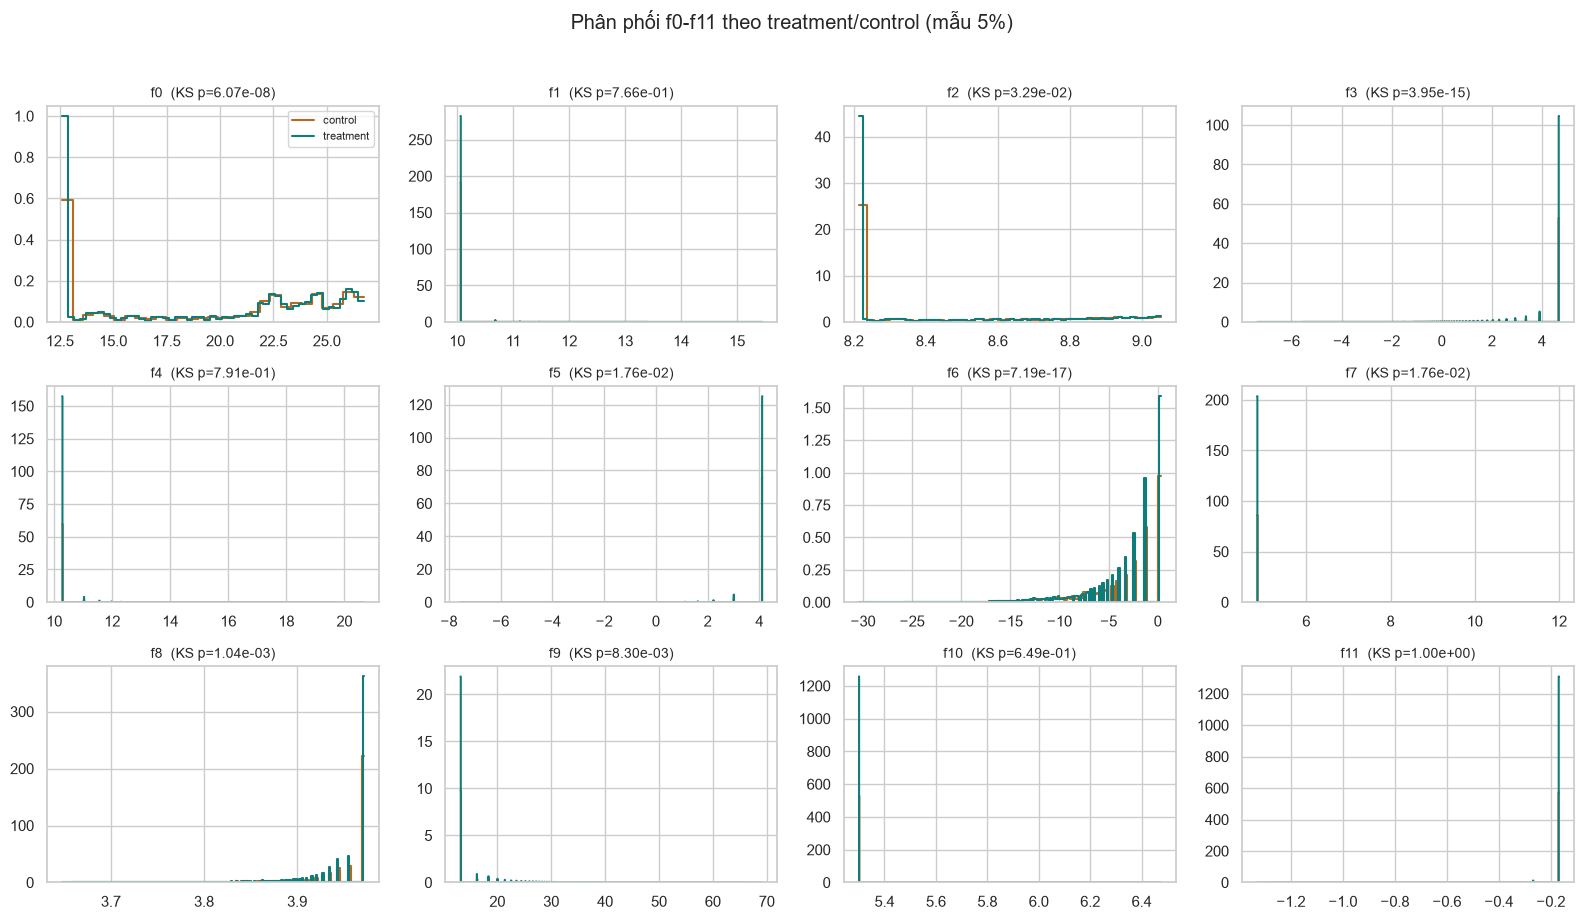

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, f in enumerate(FEATURES):
    ax = axes[i]
    sns.histplot(sample_5pct.loc[sample_5pct["treatment"] == 0, f], color=CONTROL_COLOR,
                 stat="density", element="step", fill=False, ax=ax, label="control")
    sns.histplot(sample_5pct.loc[sample_5pct["treatment"] == 1, f], color=TREATMENT_COLOR,
                 stat="density", element="step", fill=False, ax=ax, label="treatment")
    ks_p = ks_results.set_index("feature").loc[f, "p_value"]
    ax.set_title(f"{f}  (KS p={ks_p:.2e})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Phân phối f0-f11 theo treatment/control (mẫu 5%)", y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Outlier — boxplot trực quan

Bổ sung hình cho bảng `outlier_pct` ở mục 3 (đếm % nằm ngoài ±5σ) — chuẩn hoá z-score để
so sánh được nhiều feature cùng thang đo trên một biểu đồ.

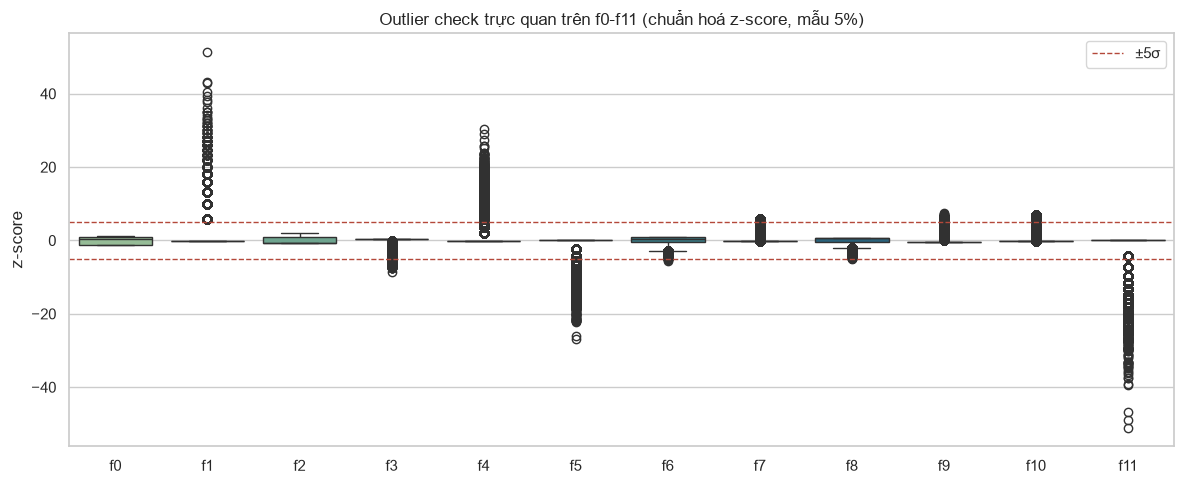

In [14]:
z = (sample_5pct[FEATURES] - sample_5pct[FEATURES].mean()) / sample_5pct[FEATURES].std()

plt.figure(figsize=(12, 5))
sns.boxplot(data=z, palette="crest")
plt.axhline(5, color="#b4483a", linestyle="--", linewidth=1, label="±5σ")
plt.axhline(-5, color="#b4483a", linestyle="--", linewidth=1)
plt.ylabel("z-score")
plt.title("Outlier check trực quan trên f0-f11 (chuẩn hoá z-score, mẫu 5%)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Tương quan giữa các đặc trưng

Kiểm tra đa cộng tuyến (multicollinearity) giữa f0-f11 trước khi đưa vào các mô hình CATE
ở Sprint 2 — các mô hình cây/gradient boosting (LightGBM, Causal Forest) chịu được tương
quan cao giữa feature, nhưng vẫn nên biết trước để diễn giải kết quả đúng.

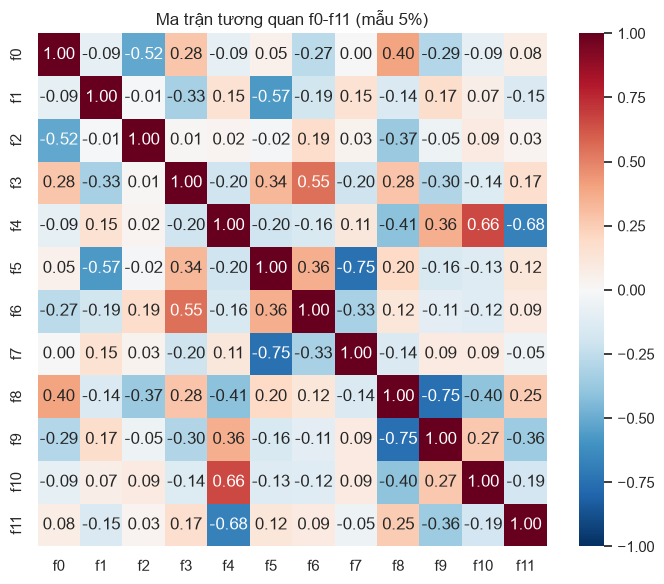

Top 5 cặp feature có hệ số tương quan tuyệt đối cao nhất:
f8   f9     0.750107
f9   f8     0.750107
f7   f5     0.745419
f5   f7     0.745419
f11  f4     0.677632
f4   f11    0.677632
     f10    0.659591
f10  f4     0.659591
f5   f1     0.574686
f1   f5     0.574686
dtype: float64


In [15]:
corr = sample_5pct[FEATURES].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Ma trận tương quan f0-f11 (mẫu 5%)")
plt.tight_layout()
plt.show()

high_corr = (
    corr.where(~np.eye(len(FEATURES), dtype=bool))
    .abs()
    .stack()
    .sort_values(ascending=False)
)
print("Top 5 cặp feature có hệ số tương quan tuyệt đối cao nhất:")
print(high_corr.head(10))

## 6. Chiến lược sample cho các giai đoạn sau

Benchmark cũ trong `planning/CAUSAL_UPLIFT_PLAN.md` chỉ dùng để tham khảo resource scaling.

- Dev/debug: sample 1-10%.
- Causal Forest cloud run phải theo resource gate trong `docs/KAGGLE_CAUSAL_FOREST.md`.
- Chỉ ghép prediction khi test-index hash khớp manifest.

Peak RAM/runtime phải được đọc từ run manifest; không thay bằng ngoại suy.

## 7. Xuất summary

In [ ]:
summary = pd.DataFrame([
    {"metric": "n_rows_full", "value": len(df)},
    {"metric": "n_cols_full", "value": df.shape[1]},
    {"metric": "treatment_rate", "value": treatment_rate},
    {"metric": "conversion_rate", "value": conversion_rate},
    {"metric": "visit_rate", "value": visit_rate},
    {"metric": "exposure_rate", "value": exposure_rate},
    {"metric": "n_missing_f0_f11_total", "value": int(missing_counts.sum())},
    {"metric": "propensity_auc_5pct_sample", "value": auc},
    {"metric": "ks_n_features_significant_5pct", "value": int(n_significant)},
    {"metric": "ks_n_features_total", "value": len(FEATURES)},
    {"metric": "balance_diagnostic_interpretation", "value": balance_diagnostic_interpretation},
])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT_DIR / "eda_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Đã ghi {out_path}")
summary


## Kết luận

- Schema: 13.979.592 dòng x 16 cột; không có missing trên f0-f11 trong file đã kiểm tra.
- Treatment/control và conversion rate được ghi trong data profile.
- Propensity AUC ở mục 4 là diagnostic, không tự chứng minh randomization.
- Causal Forest phải theo resource gate và manifest trong runbook hiện hành.